In [1]:
import jax
from jax import flatten_util, vmap, grad 
import jax.numpy as jnp
import jax.random as jr

from scipy.signal import savgol_filter
from scipy.interpolate import CubicSpline

import matplotlib.pyplot as plt
from functools import partial
import optax
from helper_fns_general import sample_gaussian_mixture, normalize_samples, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_overdamped_SDE, solve_SDE, sample_forward_process_minusx_plus_sqrt2D_dw #setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch
from plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, get_best_params
jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Generate samples from a Gaussian mixture

In [2]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 1000

# Define mixture weights (must sum to 1)
weights = jnp.array([.5, .5])

# Define means
means = jnp.array([
    [0.5, 0.0],   # mean of first Gaussian
    [-0.5, 0.5],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.01, 0.0],    # covariance of first Gaussian
        [0.0, 0.01]],
    [[0.01, 0.0],   # covariance of second Gaussian
        [0.0, 0.01]],
])

# Generate samples
samples_0 = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)



### Plot samples and marginal distributions

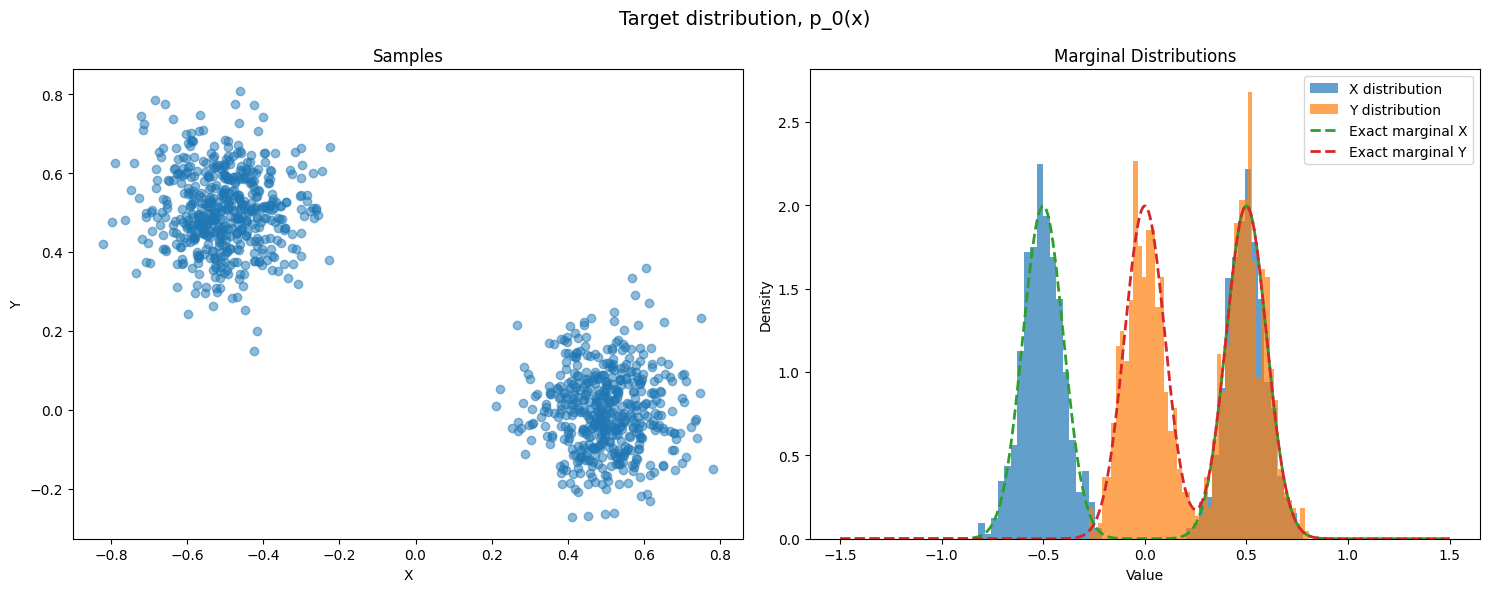

In [18]:
# ... existing code ...

# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_0[:, 0], samples_0[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_0[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_0[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

In [4]:
key, subkey = jr.split(key)
t_forward = .2
samples_t = sample_forward_process_minusx_plus_sqrt2D_dw(t_forward, n_samples, D=1, samples0=samples_0, key=subkey)

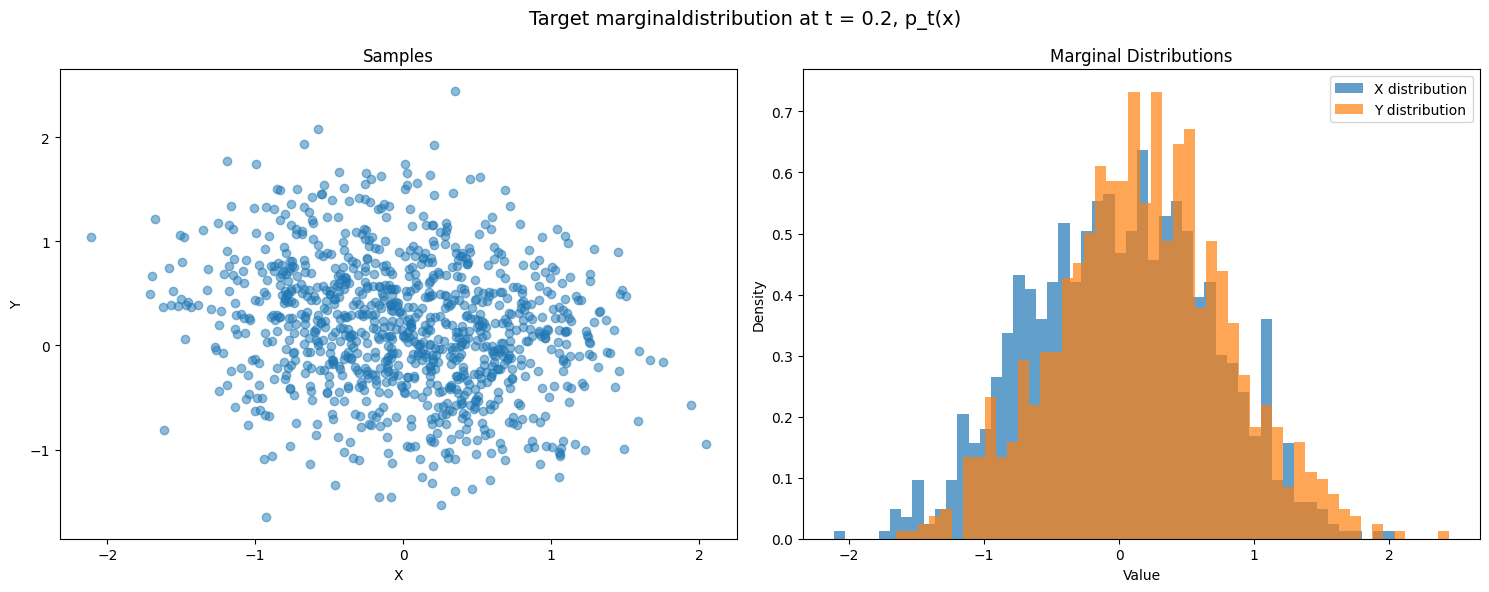

In [5]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Target marginaldistribution at t = {t_forward}, p_t(x)', fontsize=14)


# First subplot: Scatter plot of samples
ax1.scatter(samples_t[:, 0], samples_t[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_t[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_t[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')
ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Define energy function of duffing oscillator network

In [6]:
def energy_self_oscillator(x, k_lin, k_duff):
    return 1 / 2 * k_lin * x**2 + 1 / 4 * k_duff * x**4

def energy_self_network(x, k_lin, k_duff):
    return jnp.sum(vmap(energy_self_oscillator)(x, k_lin, k_duff))


def energy_coupling_pair(x, y, c_lin, c_optomech):
    return c_lin * x * (x - y) + c_lin * y * (y - x) + c_optomech * (x**2) * y

def energy_coupling_network(x, c_lin, c_optomech, connectivity):
    # get contribution to total energy from each pair of oscillators
    
    def _coupling_energy_pair(x, c_lin, c_optomech, pair):
        # get energy of one pair of oscillators
        i, j = pair
        return energy_coupling_pair(x[i], x[j], c_lin, c_optomech)

    # get energy of all pairs of oscillators
    return jnp.sum(
        vmap(_coupling_energy_pair, in_axes=(None, 0, 0, 0))(
            x, c_lin, c_optomech, connectivity
        )
    )

k_b = 1.0
T = .1
def _energy_duffing_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b=k_b, T=T):
    # returns energy of network of oscillators given input parameters
    return (
        energy_self_network(x, k_lin, k_duff) +
        energy_coupling_network(x, c_lin, c_optomech, connectivity)
    ) / (k_b * T)

### Define initial parameters

In [8]:
N_osc = 2

k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 1.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])
connectivity = jnp.array([[0, 1]])

args_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)

flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)

### Bringe energy into correct form

In [9]:
def energy_duffing_network(x, flattened_args, connectivity):
    k_lin, k_duffing, c_lin, c_optomech = unflatten(flattened_args)
    return _energy_duffing_network(x, k_lin, k_duffing, c_lin, c_optomech, connectivity)
energy_fn = lambda x, flattened_args: energy_duffing_network(x, flattened_args, connectivity)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


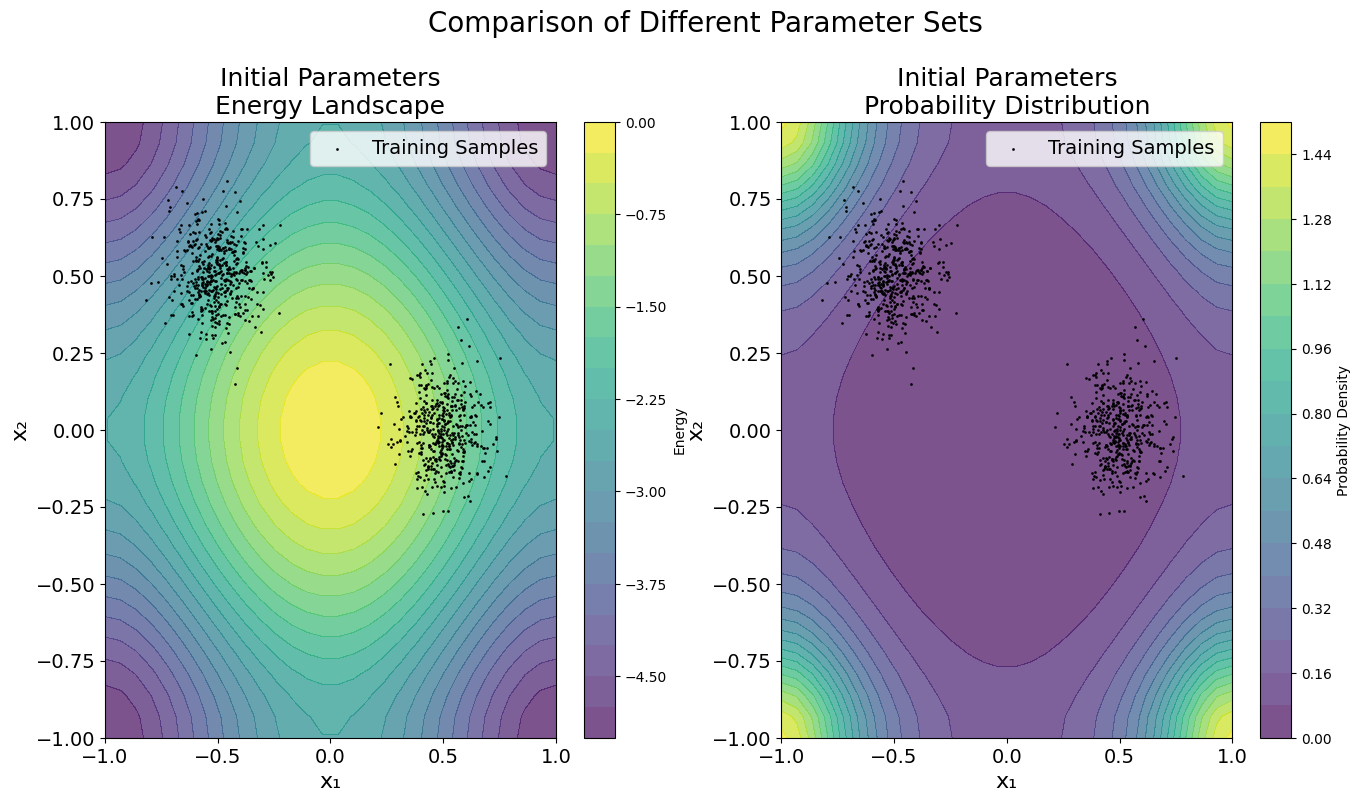

In [10]:
# Example usage:
param_list = [flattened_args_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_0,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Comparison of Different Parameter Sets" 
)

Optimizing for t = 0.000
Epoch 0
params:
[-0.99 -0.99  1.01  1.01  0.01  0.01]
Loss: 18.5905
---
Epoch 100
params:
[-0.47848018 -0.34870373  1.8346561   1.76805983  0.06616962 -0.02506583]
Loss: -12.4131
---
Epoch 200
params:
[-0.09955825  0.23670134  2.66157078  2.47285255 -0.09395164 -0.20646522]
Loss: -22.1722
---
Epoch 300
params:
[ 0.11456887  0.65450604  3.44889866  3.02696667 -0.21128356 -0.29751833]
Loss: -26.2780
---
Epoch 400
params:
[ 0.15573338  0.92103646  4.20580817  3.45330048 -0.27449875 -0.38421852]
Loss: -30.9782
---
Epoch 500
params:
[ 0.09759144  1.01975228  4.93460078  3.77822647 -0.31639813 -0.43884994]
Loss: -31.7360
---
Epoch 600
params:
[-0.01900255  1.02837894  5.65725602  4.00075628 -0.33896656 -0.45508232]
Loss: -37.6775
---
Epoch 700
params:
[-0.23411942  1.00085216  6.35767919  4.18560247 -0.33576079 -0.45616051]
Loss: -38.6490
---
Epoch 800
params:
[-0.42735041  0.94740623  7.06779269  4.38079705 -0.33963668 -0.46521636]
Loss: -45.7006
---
Epoch 900
param

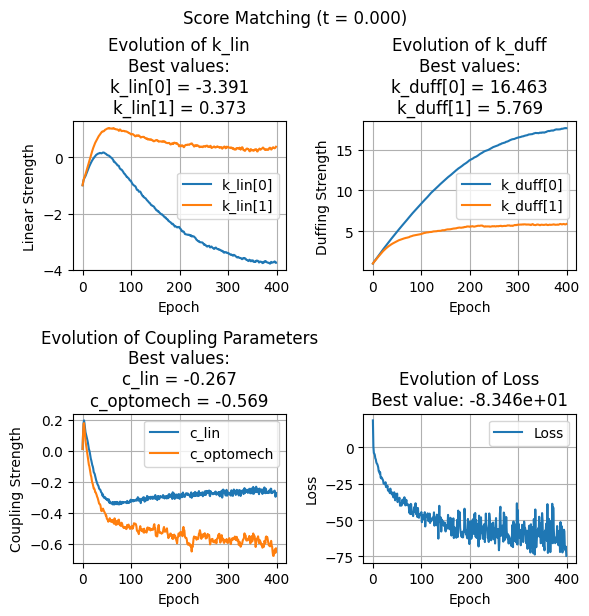

t = 0.000 probability distribution total (should be ≈ 1): 1.000000


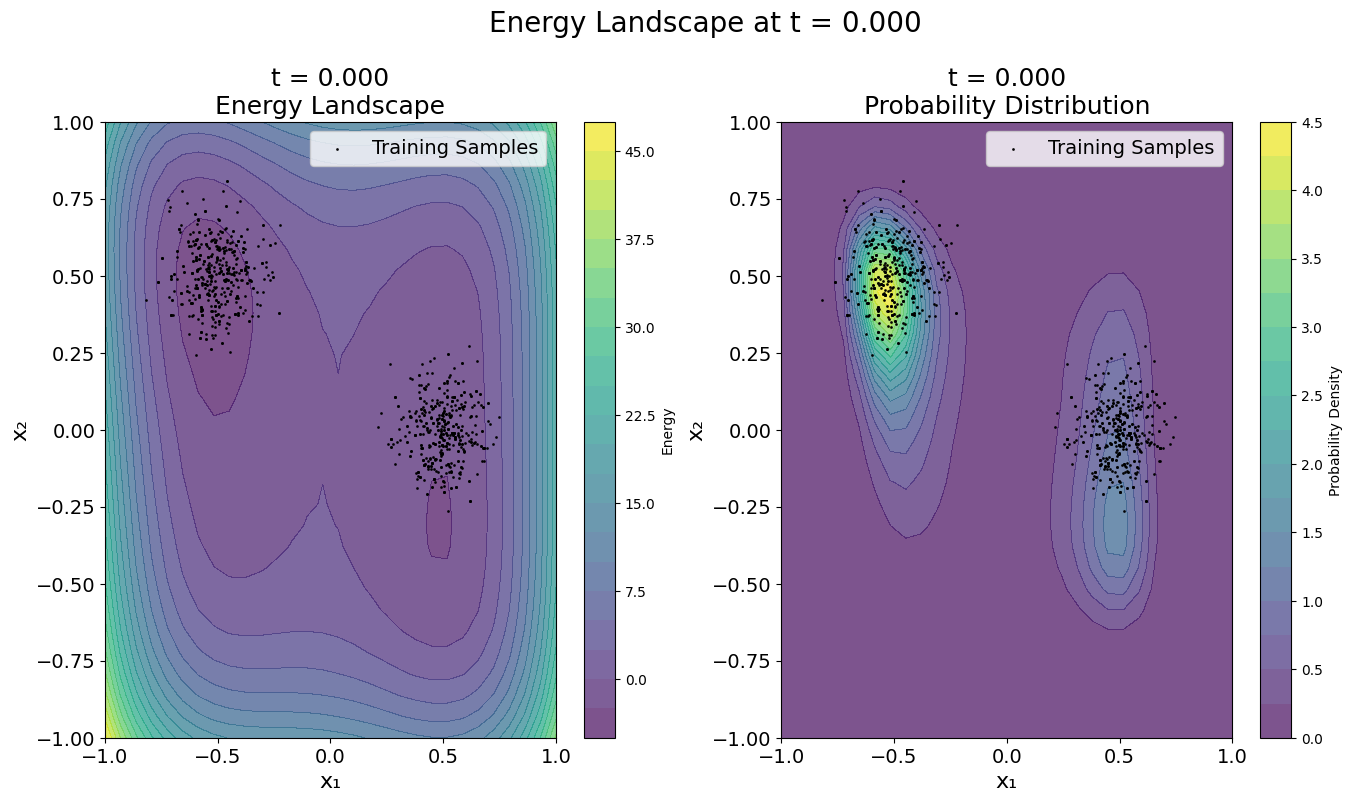

Optimizing for t = 0.002
Epoch 0
params:
[-3.40084722  0.3632563  16.45331486  5.75930333 -0.27675535 -0.55925447]
Loss: -49.1753
---
Epoch 100
params:
[-3.64249357  0.18695557 15.87338806  5.1946276  -0.20321576 -0.44141933]
Loss: -45.3000
---
Epoch 200
params:
[-3.66285577  0.09507013 15.41293255  4.78775009 -0.15998091 -0.40254232]
Loss: -46.9528
---
Epoch 300
params:
[-3.65055341  0.14775925 14.9951481   4.62186532 -0.18563969 -0.39310439]
Loss: -39.4140
---
Epoch 400
params:
[-3.53428242  0.1743915  14.67034755  4.39692016 -0.15527303 -0.36996677]
Loss: -33.3592
---
Epoch 500
params:
[-3.42745704  0.23660581 14.41924641  4.22132643 -0.16416265 -0.36132651]
Loss: -38.0386
---
Epoch 600
params:
[-3.3257436   0.21355894 14.07853368  4.10340684 -0.18291732 -0.34967929]
Loss: -31.4580
---
Epoch 700
params:
[-3.22027774  0.32270036 13.88615377  3.89241409 -0.14771126 -0.35462258]
Loss: -36.8469
---
Epoch 800
params:
[-3.16514014  0.39400576 13.65735586  3.79276173 -0.1885984  -0.3982052

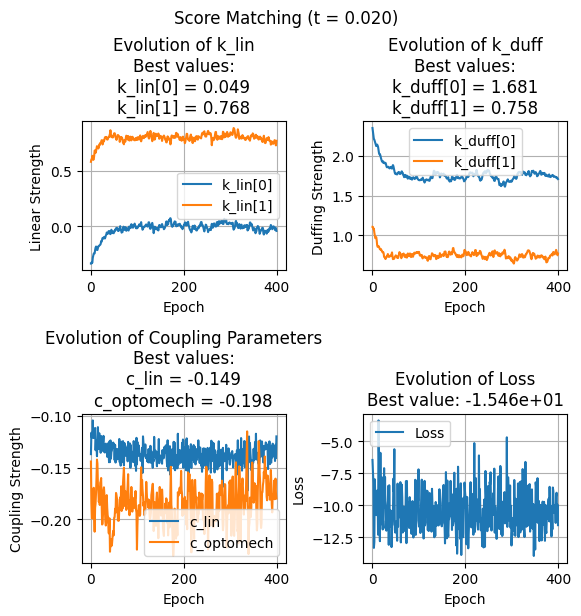

t = 0.020 probability distribution total (should be ≈ 1): 1.000000


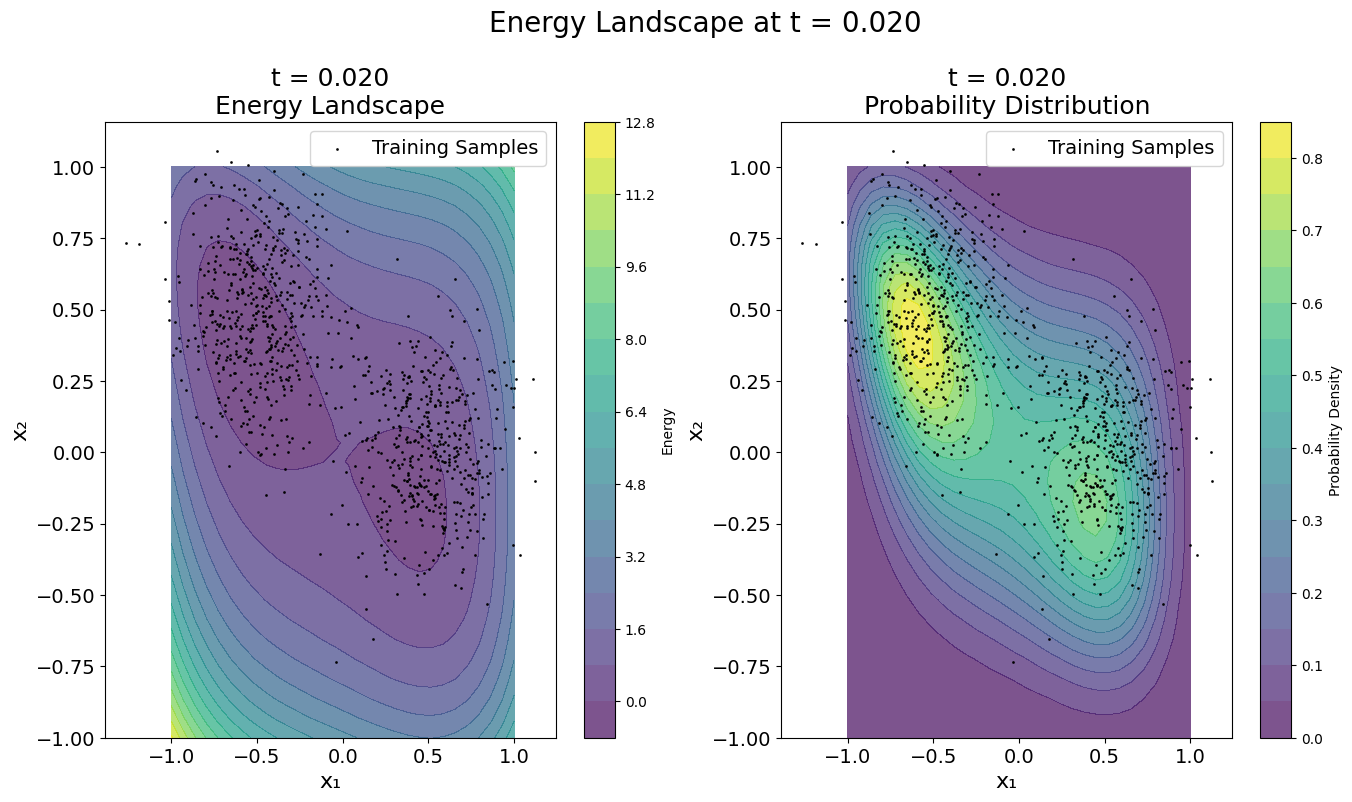

Optimizing for t = 0.022
Epoch 0
params:
[ 0.03930501  0.77804666  1.67146552  0.74824726 -0.13938541 -0.18774616]
Loss: -7.2810
---
Epoch 100
params:
[-0.00314228  0.77768908  1.56839662  0.4754558  -0.11964854 -0.11916157]
Loss: -11.9283
---
Epoch 200
params:
[ 0.01252259  0.86852367  1.56413127  0.38778707 -0.13570063 -0.13461083]
Loss: -7.7001
---
Epoch 300
params:
[ 0.03017688  0.87927378  1.53228839  0.37735061 -0.12802731 -0.16234928]
Loss: -10.7729
---
Epoch 400
params:
[ 0.02642596  0.90649007  1.52467767  0.43414976 -0.13685312 -0.13067939]
Loss: -9.6607
---
Epoch 500
params:
[ 0.03442344  0.86429671  1.53560062  0.35825609 -0.12678717 -0.10046174]
Loss: -9.4822
---
Epoch 600
params:
[ 0.05089755  0.81413815  1.4938853   0.35529461 -0.14092767 -0.10653056]
Loss: -10.3200
---
Epoch 700
params:
[ 0.06209831  0.82561574  1.49837565  0.33922312 -0.13795937 -0.10279921]
Loss: -8.0387
---
Epoch 800
params:
[ 0.0421652   0.83525129  1.53263503  0.38502143 -0.13529725 -0.11560554]
Lo

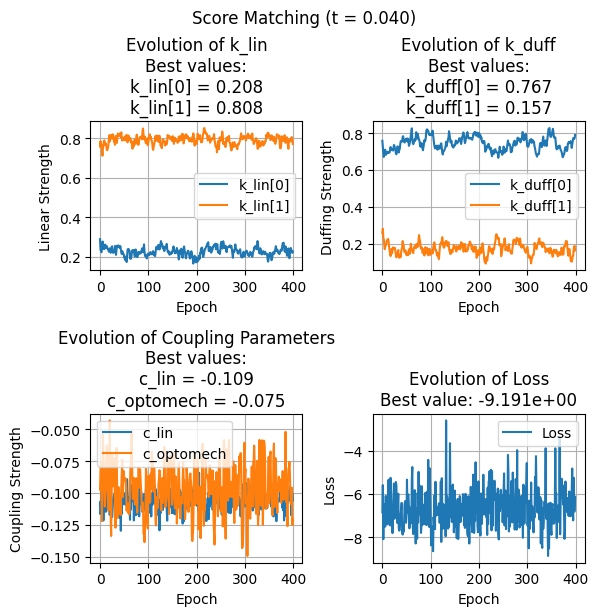

t = 0.040 probability distribution total (should be ≈ 1): 1.000000


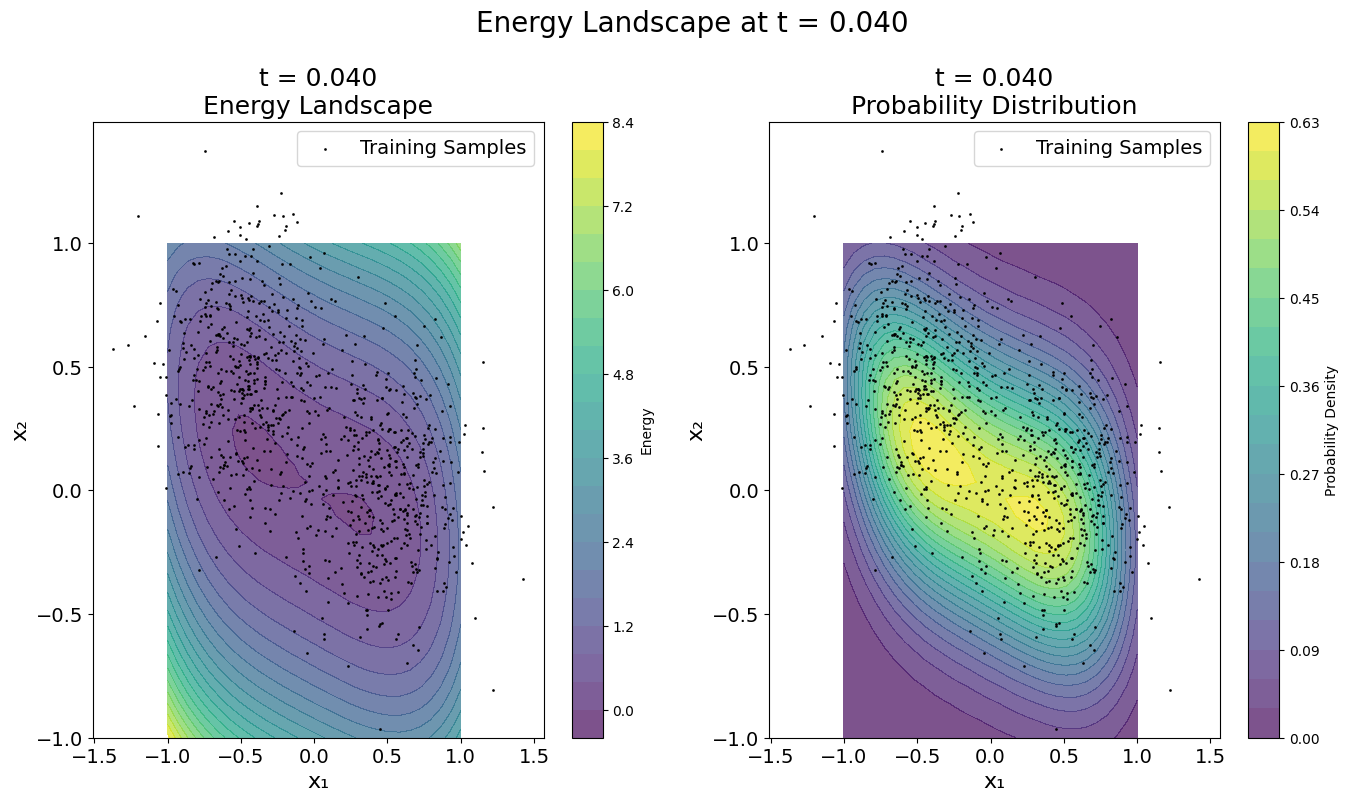

Optimizing for t = 0.042
Epoch 0
params:
[ 0.21820761  0.79849874  0.75719957  0.16683173 -0.11876964 -0.06498607]
Loss: -5.6713
---
Epoch 100
params:
[ 0.294474    0.62297296  0.50907719  0.34932707 -0.10646327 -0.11149363]
Loss: -5.6651
---
Epoch 200
params:
[ 0.34256272  0.58073891  0.4702187   0.44797032 -0.10197531 -0.12363878]
Loss: -5.5300
---
Epoch 300
params:
[ 0.37675983  0.55446236  0.42616241  0.49504883 -0.10697807 -0.07799271]
Loss: -6.7229
---
Epoch 400
params:
[ 0.41453297  0.55682135  0.42311659  0.45449829 -0.10302637 -0.06749369]
Loss: -4.6471
---
Epoch 500
params:
[ 0.40658139  0.55679442  0.4481955   0.49292707 -0.11020519 -0.07106918]
Loss: -6.9468
---
Epoch 600
params:
[ 0.41357272  0.55826605  0.44498784  0.48626744 -0.11528058 -0.06788124]
Loss: -5.8909
---
Epoch 700
params:
[ 0.37051114  0.53080939  0.40698454  0.42093053 -0.10114997 -0.07626844]
Loss: -6.4989
---
Epoch 800
params:
[ 0.38018442  0.57570085  0.39522769  0.39682898 -0.0948415  -0.07359162]
Loss:

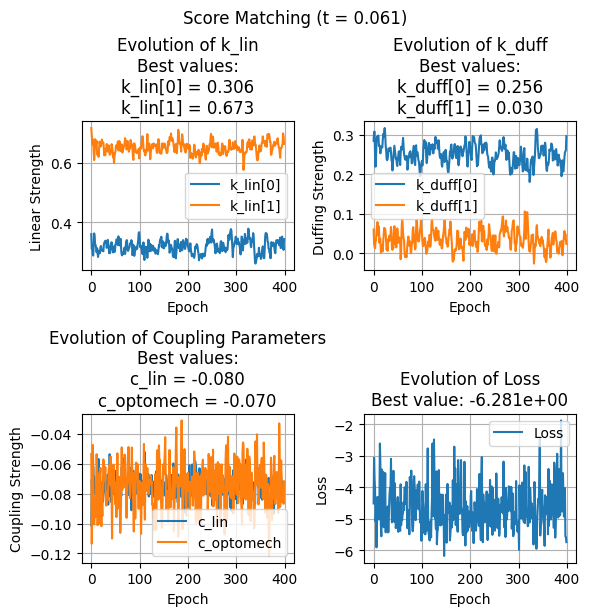

t = 0.061 probability distribution total (should be ≈ 1): 1.000000


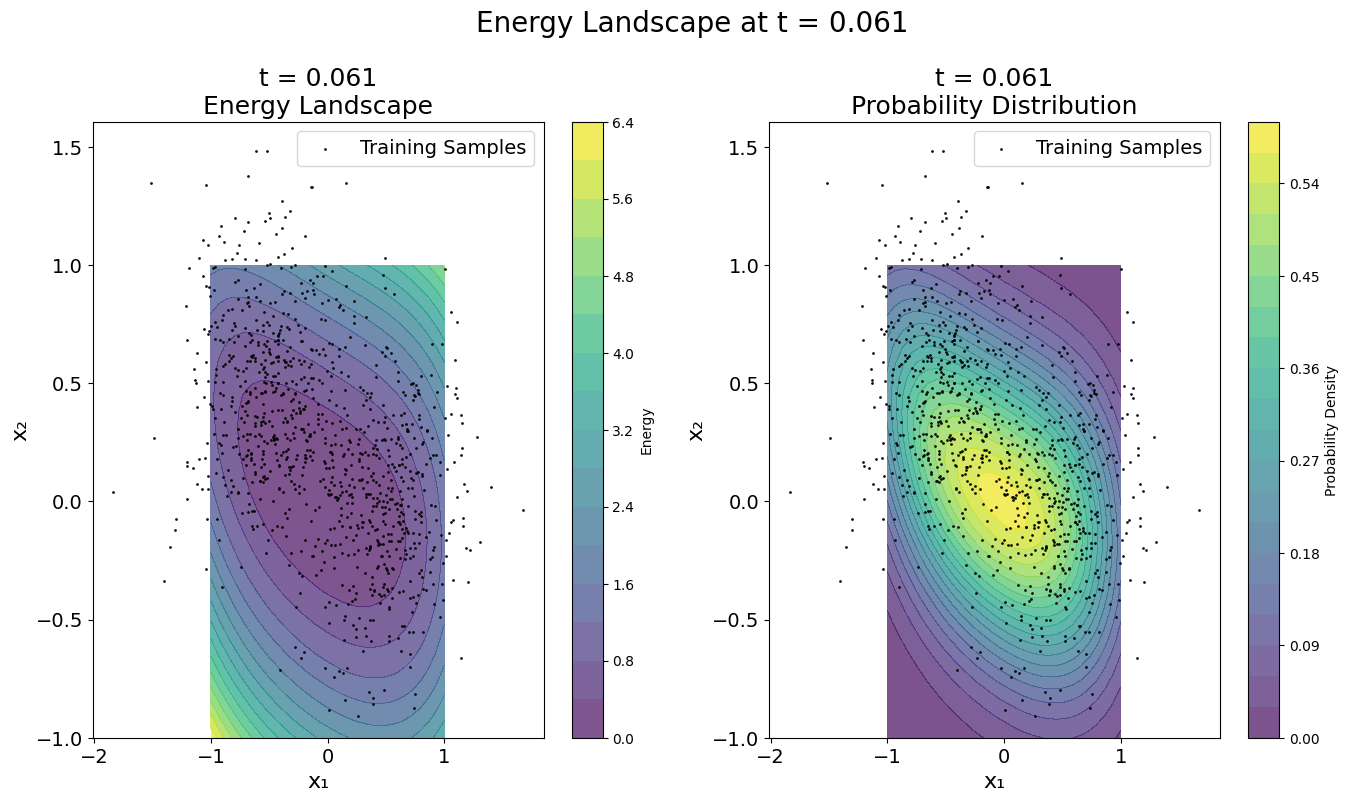

Optimizing for t = 0.063
Epoch 0
params:
[ 0.31594933  0.68277038  0.26576139  0.02046781 -0.06985575 -0.06001754]
Loss: -5.2435
---
Epoch 100
params:
[ 0.28601463  0.61157565  0.30967725  0.10647412 -0.07718843 -0.07399045]
Loss: -4.9619
---
Epoch 200
params:
[ 0.27061625  0.58949453  0.27757277  0.04630547 -0.07167709 -0.07210886]
Loss: -4.5803
---
Epoch 300
params:
[ 0.32946232  0.60357509  0.28511088  0.07805388 -0.07802275 -0.05036472]
Loss: -3.8474
---
Epoch 400
params:
[ 0.3083276   0.60872851  0.26107082  0.10485562 -0.07175205 -0.04638264]
Loss: -4.4812
---
Epoch 500
params:
[ 0.2811627   0.56209957  0.25194663  0.06536412 -0.07243744 -0.04288567]
Loss: -3.7896
---
Epoch 600
params:
[ 0.30807408  0.61798206  0.26548138  0.0929293  -0.07712009 -0.08421583]
Loss: -4.8244
---
Epoch 700
params:
[ 0.27044727  0.61523947  0.27536704  0.07775489 -0.0681842  -0.08293578]
Loss: -4.3080
---
Epoch 800
params:
[ 0.26586119  0.60632669  0.26978304  0.0895015  -0.07659886 -0.06763287]
Loss:

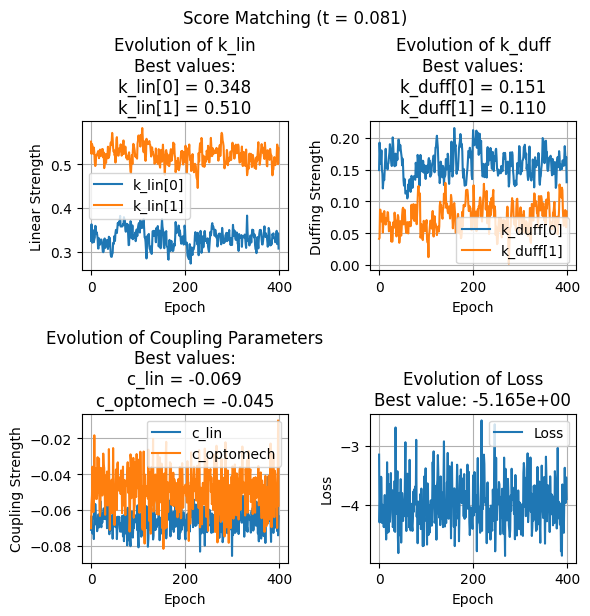

t = 0.081 probability distribution total (should be ≈ 1): 1.000000


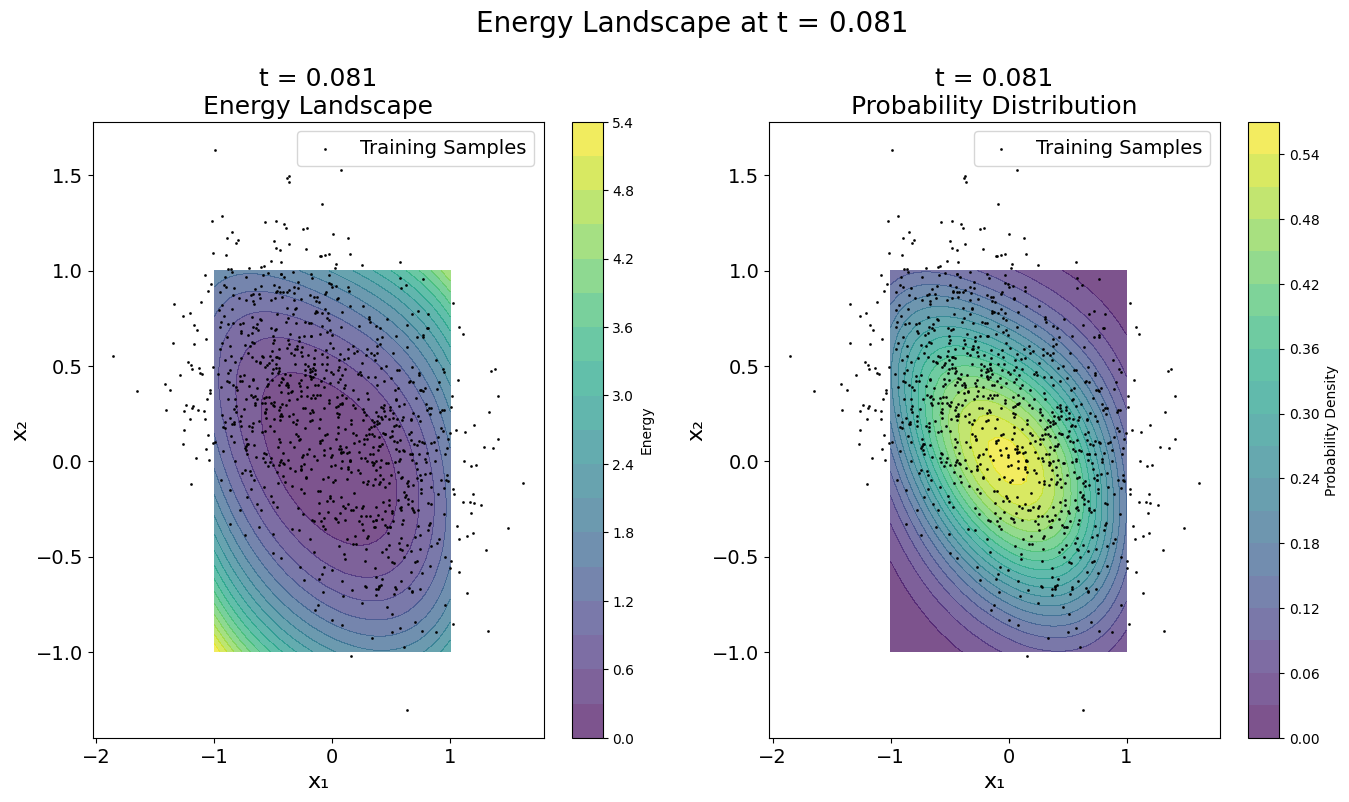

Optimizing for t = 0.083
Epoch 0
params:
[ 0.33757043  0.50025091  0.16114203  0.09982828 -0.05914452 -0.05472116]
Loss: -3.5966
---
Epoch 100
params:
[ 0.34993364  0.43851825  0.11537906  0.12740277 -0.05733743 -0.05752293]
Loss: -3.7082
---
Epoch 200
params:
[ 0.31416518  0.41917563  0.12018945  0.13095568 -0.05273242 -0.06119302]
Loss: -4.5284
---
Epoch 300
params:
[ 0.3236295   0.46003017  0.11489773  0.06738347 -0.05935625 -0.04642799]
Loss: -3.6897
---
Epoch 400
params:
[ 0.34393148  0.44495783  0.11506035  0.11214368 -0.05062374 -0.0566934 ]
Loss: -3.4608
---
Epoch 500
params:
[ 0.34893473  0.45689247  0.14083368  0.11826927 -0.04691348 -0.07918668]
Loss: -4.2439
---
Epoch 600
params:
[ 0.3546315   0.41153125  0.10670173  0.0989658  -0.05755139 -0.04985324]
Loss: -3.3975
---
Epoch 700
params:
[ 0.35048973  0.42297111  0.08089699  0.14124162 -0.05426707 -0.03855768]
Loss: -4.0181
---
Epoch 800
params:
[ 0.30354185  0.47358497  0.12054893  0.07049631 -0.05349038 -0.06921568]
Loss:

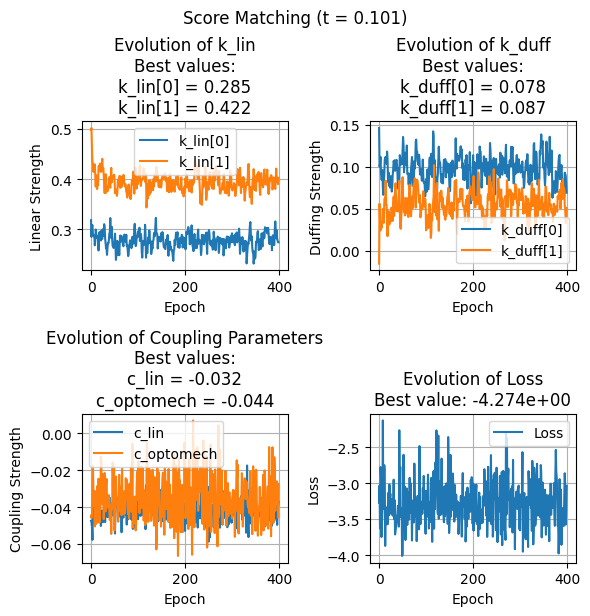

t = 0.101 probability distribution total (should be ≈ 1): 1.000000


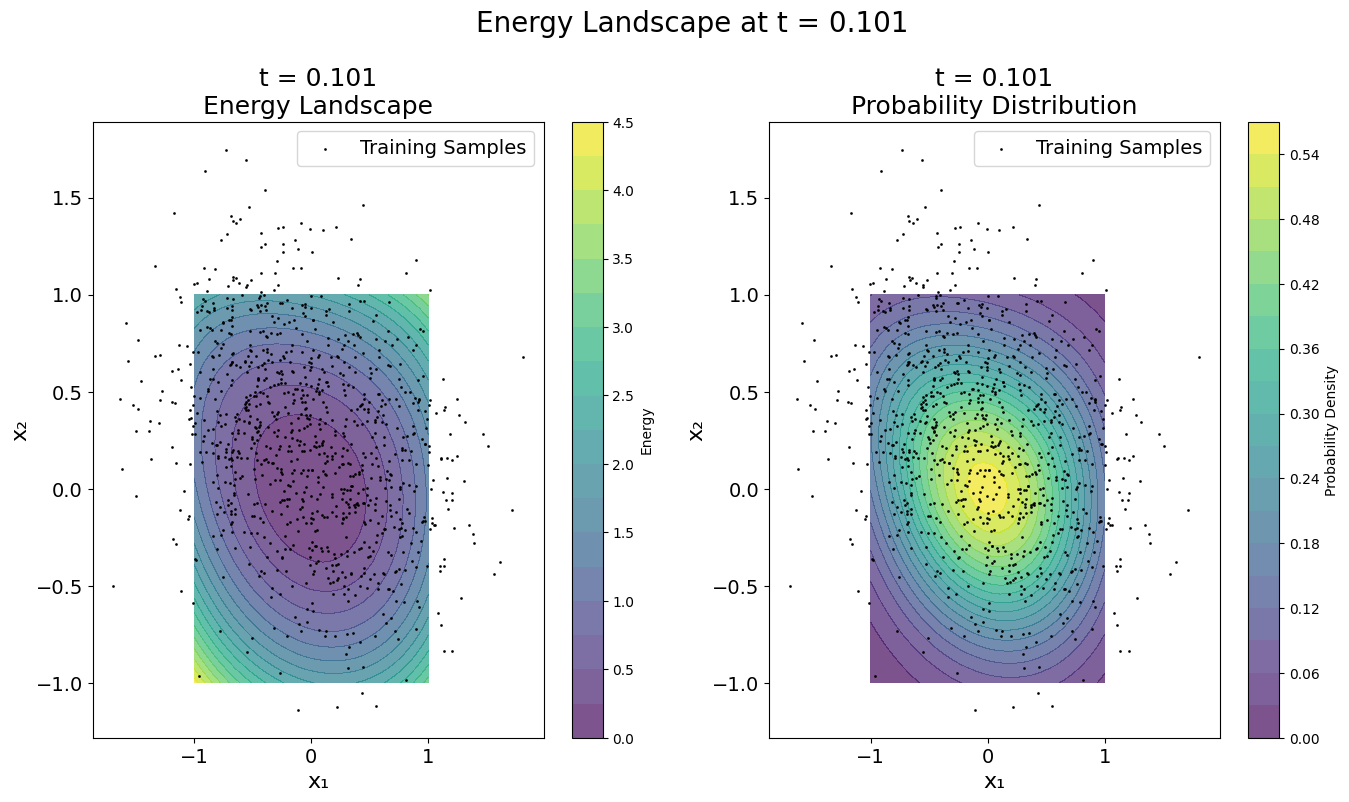

Optimizing for t = 0.103
Epoch 0
params:
[ 0.27452447  0.41192579  0.08818374  0.07747583 -0.0416067  -0.03360913]
Loss: -3.1404
---
Epoch 100
params:
[ 0.29015208  0.43062446  0.09694392  0.0250064  -0.0467075  -0.03613565]
Loss: -3.5480
---
Epoch 200
params:
[ 0.25310845  0.42502743  0.1042175   0.03038173 -0.04164374 -0.05015803]
Loss: -3.6987
---
Epoch 300
params:
[ 0.27240572  0.41619441  0.11538423  0.04494673 -0.0456125  -0.03208764]
Loss: -3.1388
---
Epoch 400
params:
[ 0.26522177  0.42703386  0.11840721  0.05083433 -0.04477749 -0.03976529]
Loss: -2.8820
---
Epoch 500
params:
[ 0.27478748  0.40062571  0.08179313  0.02263084 -0.0428421  -0.03136446]
Loss: -3.3256
---
Epoch 600
params:
[ 0.31756732  0.44655458  0.10762338  0.04727161 -0.05054389 -0.02721126]
Loss: -3.0869
---
Epoch 700
params:
[ 0.26989678  0.42834293  0.09620018  0.02230305 -0.02427784 -0.02770469]
Loss: -3.4800
---
Epoch 800
params:
[ 0.25561089  0.44957999  0.10998302  0.01708707 -0.03941785 -0.0292637 ]
Loss:

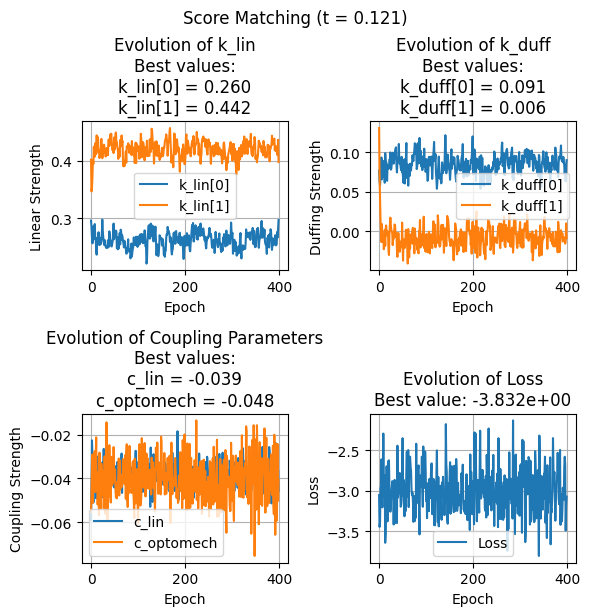

t = 0.121 probability distribution total (should be ≈ 1): 1.000000


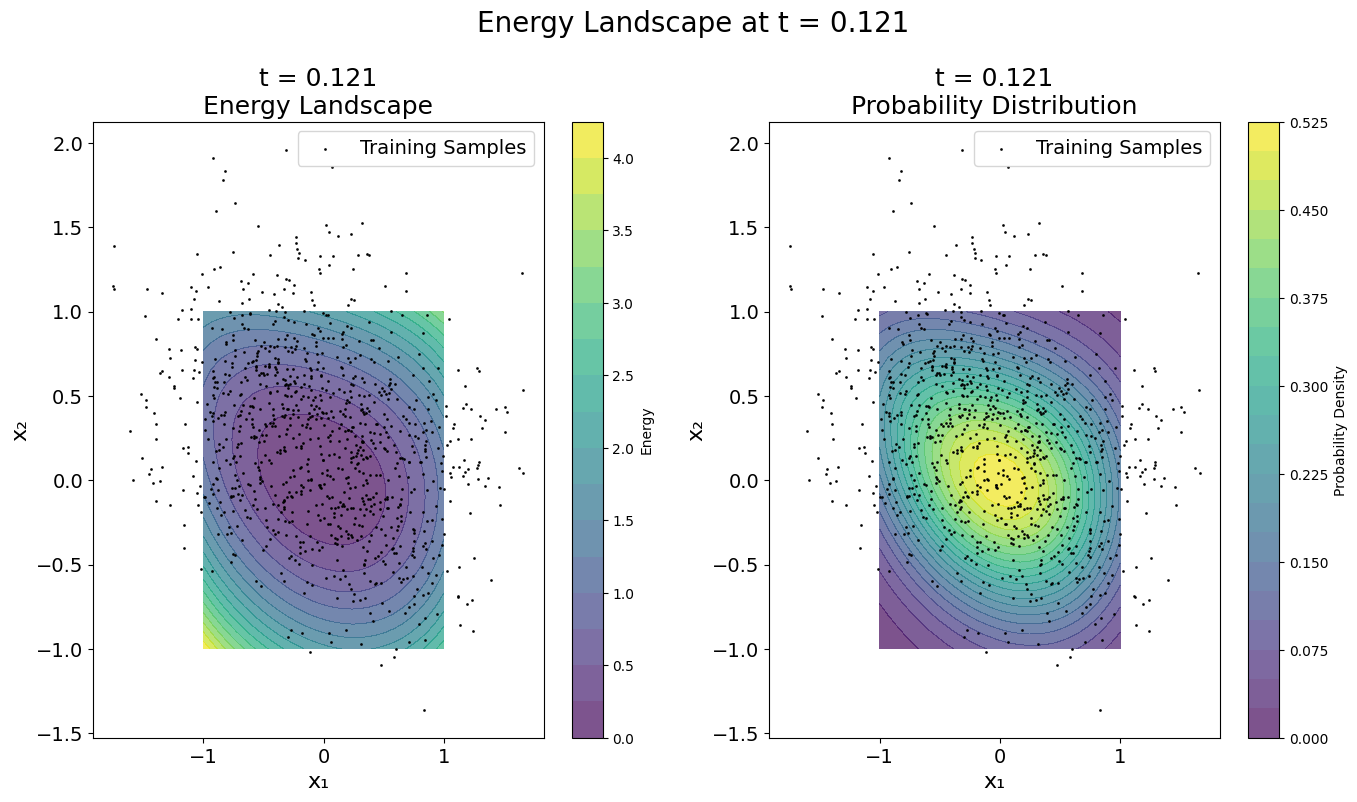

Optimizing for t = 0.123
Epoch 0
params:
[ 0.24956596  0.43243581  0.10074895 -0.00385326 -0.04912638 -0.05777436]
Loss: -3.1577
---
Epoch 100
params:
[ 0.22511104  0.38452188  0.09187045  0.03953172 -0.03880368 -0.02120544]
Loss: -2.9632
---
Epoch 200
params:
[ 0.24680075  0.40417734  0.09128426  0.034265   -0.03866524 -0.02311341]
Loss: -2.7292
---
Epoch 300
params:
[ 0.23799896  0.3837572   0.08980994  0.02878728 -0.03146996 -0.01418064]
Loss: -3.2361
---
Epoch 400
params:
[ 0.2231327   0.39742649  0.08666103  0.04356892 -0.04009565 -0.02247501]
Loss: -3.3115
---
Epoch 500
params:
[ 0.22408593  0.41595642  0.08924943  0.02992272 -0.03261115 -0.03986869]
Loss: -3.5772
---
Epoch 600
params:
[ 0.24547639  0.40870219  0.10762653  0.03484057 -0.03821013 -0.03037845]
Loss: -2.9542
---
Epoch 700
params:
[ 0.23913612  0.38607583  0.11405317  0.02054096 -0.03399105 -0.03432133]
Loss: -3.4111
---
Epoch 800
params:
[ 0.24391134  0.39224424  0.09090146  0.02593929 -0.04249473 -0.02004628]
Loss:

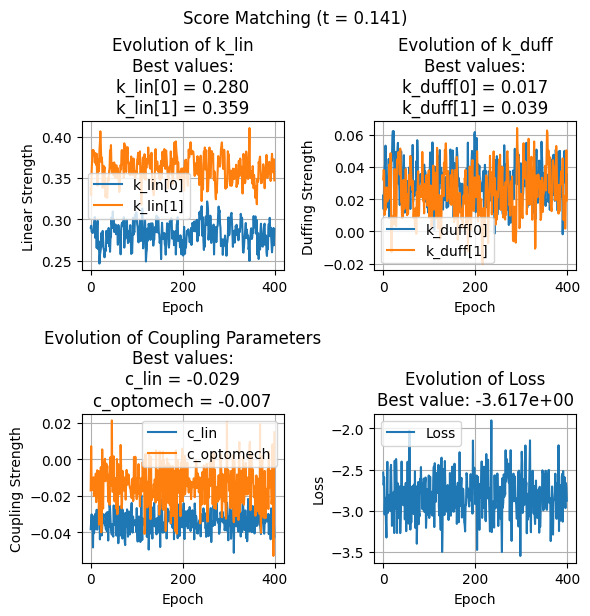

t = 0.141 probability distribution total (should be ≈ 1): 1.000000


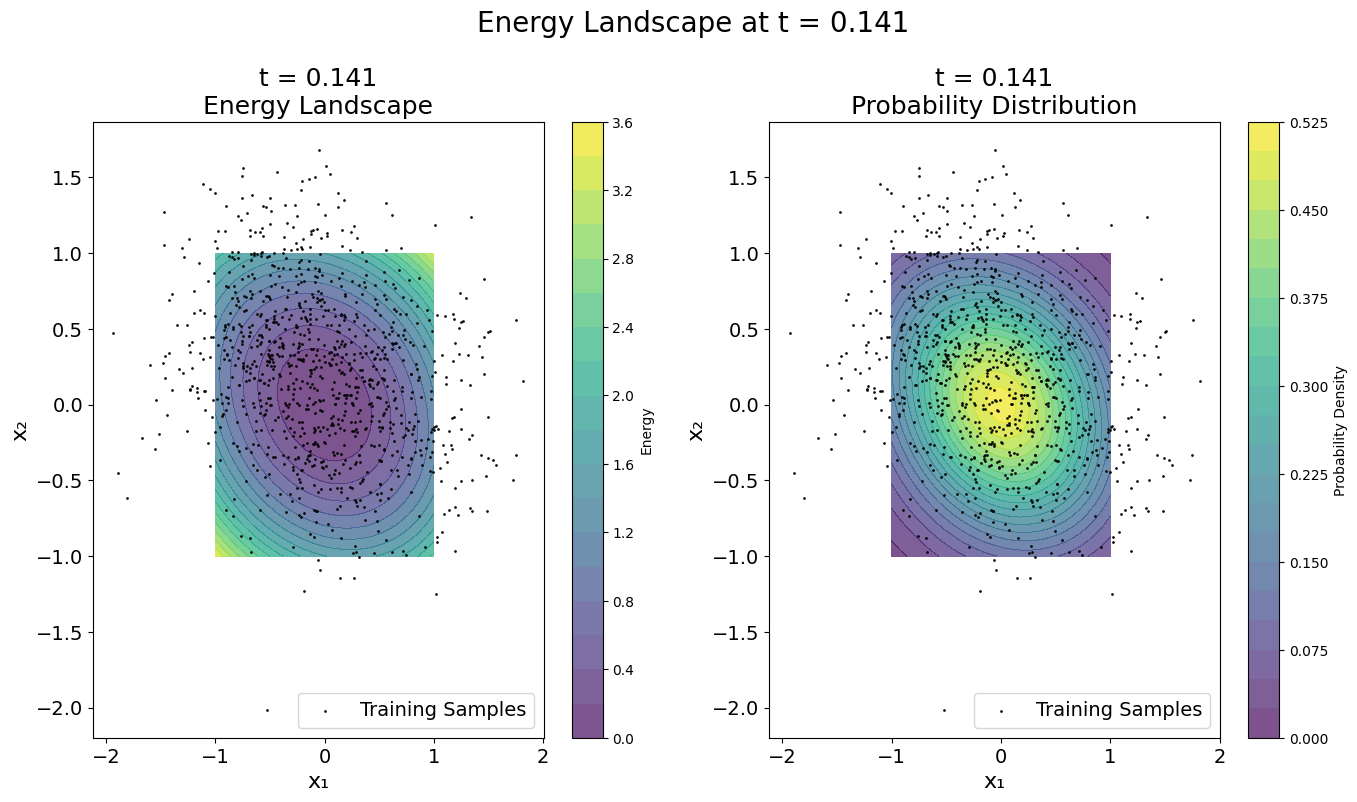

Optimizing for t = 0.143
Epoch 0
params:
[ 0.29030425  0.34948144  0.00748964  0.02939228 -0.0388721  -0.01708571]
Loss: -2.7061
---
Epoch 100
params:
[ 0.31732216  0.30560395  0.00032523  0.06794608 -0.04136702 -0.00832555]
Loss: -2.6566
---
Epoch 200
params:
[ 0.33586146  0.29292996 -0.00035354  0.08033883 -0.03894194 -0.0184246 ]
Loss: -2.7622
---
Epoch 300
params:
[ 0.31777589  0.31392505  0.03347171  0.07040137 -0.04341771 -0.01187516]
Loss: -3.1319
---
Epoch 400
params:
[ 0.34734534  0.30482307 -0.01291329  0.06201341 -0.02705053  0.00349607]
Loss: -3.2073
---
Epoch 500
params:
[ 0.3111845   0.29464543  0.00904697  0.08924494 -0.03055724 -0.01300014]
Loss: -3.0792
---
Epoch 600
params:
[ 0.31302018  0.31682128  0.00324349  0.0750155  -0.03562164 -0.00568901]
Loss: -3.1828
---
Epoch 700
params:
[ 0.34324741  0.30996205  0.00739002  0.07711013 -0.04191622 -0.01712478]
Loss: -2.8553
---
Epoch 800
params:
[ 0.33791735  0.32329854 -0.01190022  0.07338844 -0.03749603 -0.00192274]
Loss:

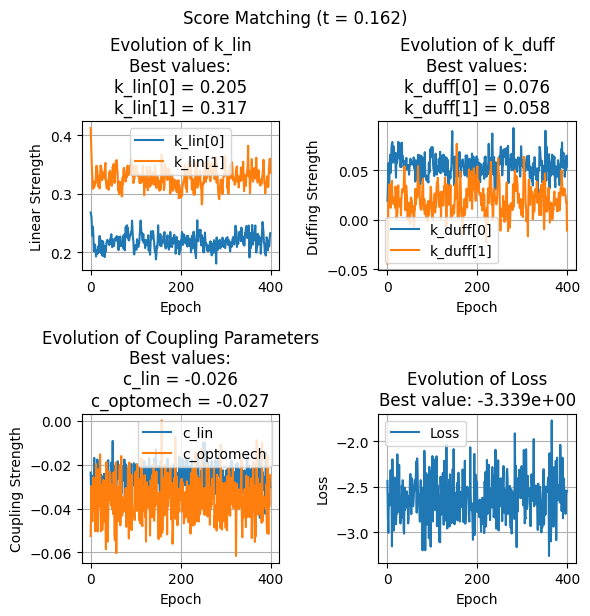

t = 0.162 probability distribution total (should be ≈ 1): 1.000000


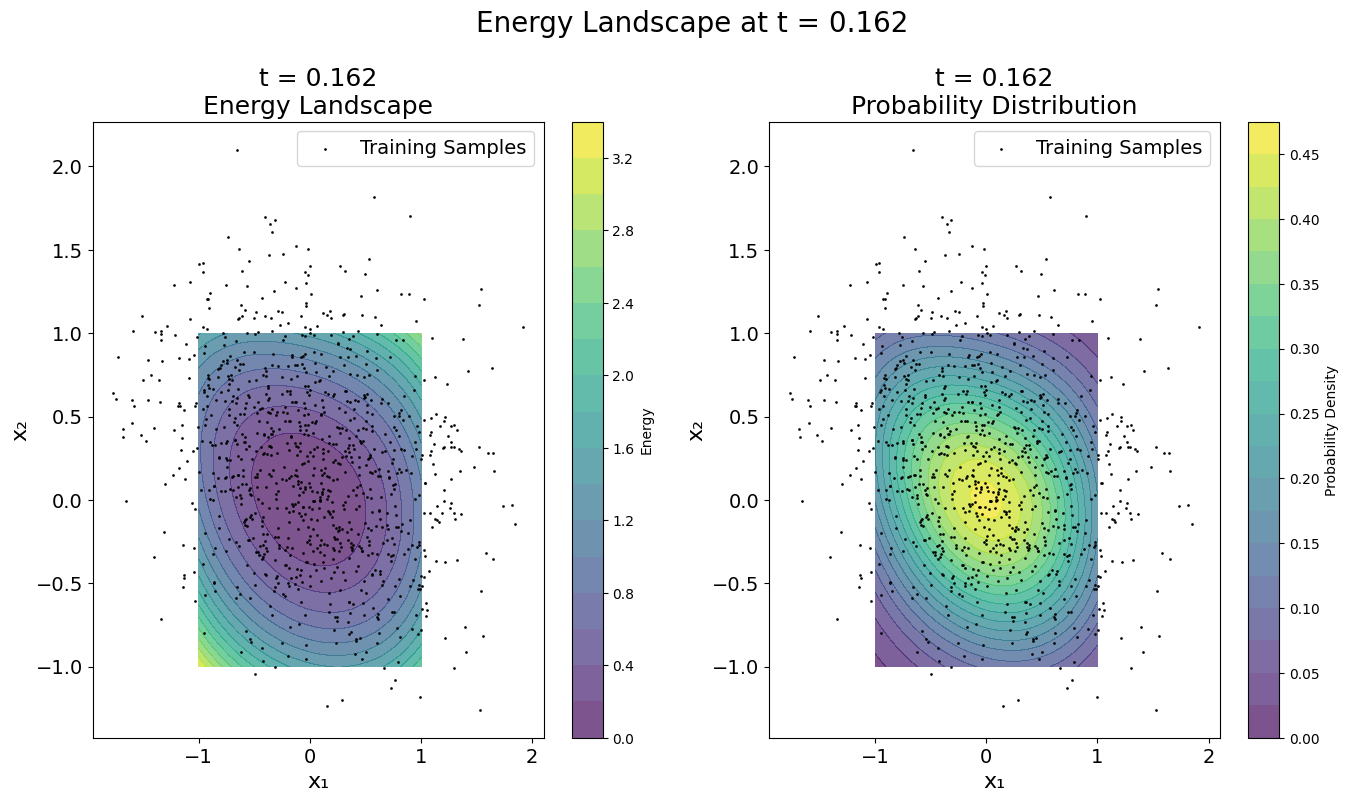

Optimizing for t = 0.164
Epoch 0
params:
[ 0.21489211  0.30686527  0.08551952  0.04788452 -0.01643806 -0.01686177]
Loss: -2.7978
---
Epoch 100
params:
[ 0.32431111  0.3078225   0.00145557  0.0087028  -0.03642669 -0.02986315]
Loss: -2.5244
---
Epoch 200
params:
[ 0.29174015  0.30315166  0.00902743  0.00598896 -0.02463567 -0.02816851]
Loss: -2.7896
---
Epoch 300
params:
[ 0.30143796  0.3201197   0.00466486 -0.00404323 -0.03331258 -0.00730512]
Loss: -2.2616
---
Epoch 400
params:
[ 0.29917455  0.31805366 -0.01336342  0.01240068 -0.03262585 -0.02275874]
Loss: -2.2294
---
Epoch 500
params:
[ 0.31605925  0.30553088  0.00168242 -0.0051074  -0.03519872 -0.03115049]
Loss: -2.4970
---
Epoch 600
params:
[ 0.30011002  0.31509671 -0.01221868  0.03618739 -0.03279974 -0.02410439]
Loss: -2.7957
---
Epoch 700
params:
[ 3.20282983e-01  3.30397308e-01  2.45962888e-04  1.93903942e-02
 -3.33915912e-02 -1.74543014e-02]
Loss: -2.8165
---
Epoch 800
params:
[ 0.3113751   0.31925166  0.00620596  0.01685299 -0.02

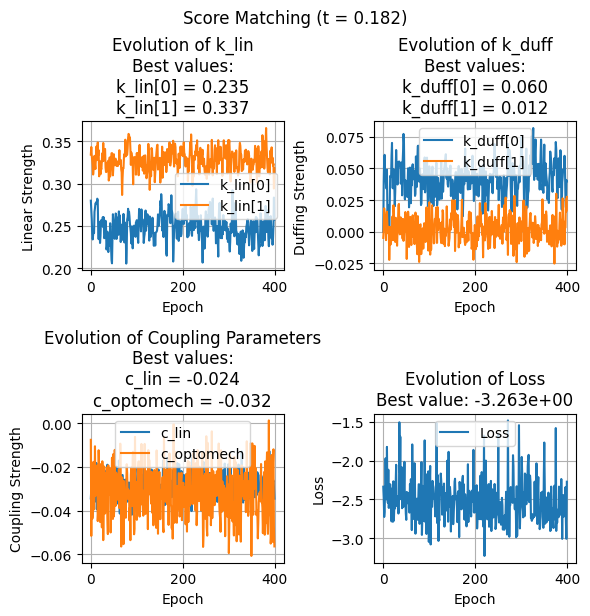

t = 0.182 probability distribution total (should be ≈ 1): 1.000000


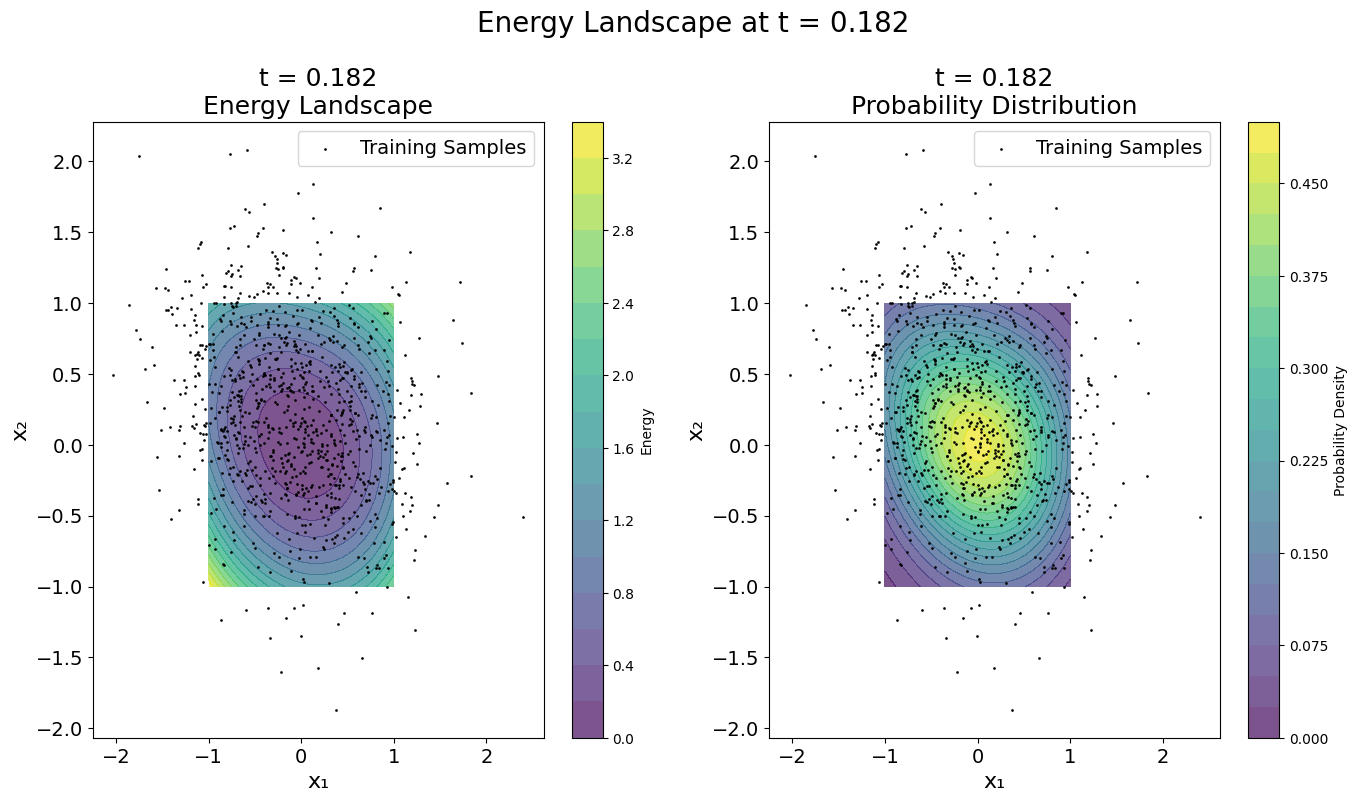

Optimizing for t = 0.184
Epoch 0
params:
[ 0.22535764  0.32695977  0.04996259  0.00177761 -0.03382193 -0.02233549]
Loss: -1.4159
---
Epoch 100
params:
[ 0.24140246  0.34228923  0.00506281 -0.01430586 -0.02728069 -0.00424597]
Loss: -2.3269
---
Epoch 200
params:
[ 0.23251621  0.35669987  0.01575826 -0.02926529 -0.0286146  -0.02169894]
Loss: -2.2773
---
Epoch 300
params:
[ 0.2539862   0.36315961  0.00534166 -0.00471024 -0.02996167 -0.01771789]
Loss: -2.1892
---
Epoch 400
params:
[ 0.22562346  0.35420349  0.00594522 -0.02610357 -0.02452886 -0.01291346]
Loss: -2.1723
---
Epoch 500
params:
[ 0.2253909   0.37063385  0.00992131 -0.00934526 -0.02156674 -0.01061716]
Loss: -2.5700
---
Epoch 600
params:
[ 0.24401937  0.37018194  0.00850888 -0.0345914  -0.01917081 -0.01157439]
Loss: -2.8647
---
Epoch 700
params:
[ 0.24088933  0.3476212   0.00958539 -0.02563255 -0.0290022  -0.01021484]
Loss: -2.3850
---
Epoch 800
params:
[ 0.24915234  0.34906562  0.01152928 -0.0236779  -0.03436226 -0.01469718]
Loss:

In [11]:
# Choose loss function and gradient function
loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
gradient_fn_per_batch = None
maximize = False

# Setup optimization parameters
n_time_steps = 100
forward_time_pts = jnp.linspace(0., .2, n_time_steps)
learning_rate = 0.01
n_epochs = 4000
batch_size = 128

# Plotting parameters
plot_steps = True  # Flag to control whether to plot during optimization
plot_slice = 10     # Plot every nth step


# Initialize storage for parameters at each time step
params_history_all_t = []
current_params = flattened_args_initial

# Loop over time points
for t_idx, t_forward in enumerate(forward_time_pts):
    print(f"Optimizing for t = {t_forward:.3f}")
    
    # Generate samples at current time
    key, subkey = jr.split(key)
    samples_t = sample_forward_process_minusx_plus_sqrt2D_dw(
        t_forward, n_samples, D=1, samples0=samples_0, key=subkey
    )
    
    # Perform optimization starting from previous best parameters
    key, subkey = jr.split(key)
    
    params_history, loss_history = run_optimization(
        loss_fn_per_batch=loss_fn_per_batch,
        params_initial=current_params,
        samples=samples_t,
        gradient_fn_per_batch=gradient_fn_per_batch,
        key=subkey,
        batch_size=batch_size,
        learning_rate=learning_rate,
        n_epochs=n_epochs,
        maximize=maximize
    )
    
    _, best_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
    k_lin_best, k_duff_best, c_lin_best, c_optomech_best = unflatten(best_params)
    current_params, _ = flatten_util.ravel_pytree(best_params)
    params_history_all_t.append(current_params)
    
    if plot_steps and t_idx % plot_slice == 0:
        # Plot optimization progress
        plot_parameter_evolution(
            params_history=params_history,
            loss_history=loss_history,
            unflatten=unflatten,
            N_osc=N_osc,
            slicing=10,
            title=f"Score Matching (t = {t_forward:.3f})",
            maximize=maximize
        )
        # Plot current energy landscape
        plot_energy_and_distributions(
            energy_fn=energy_fn,
            param_list=[current_params],
            samples=samples_t,
            x1_range=(-1, 1),
            x2_range=(-1, 1),
            n_points=30,
            titles=[f"t = {t_forward:.3f}"],
            fontsize=16,
            sample_stride=1,
            suptitle=f"Energy Landscape at t = {t_forward:.3f}"
        )
    
# Convert params_history_all_t to array for easier analysis
params_history_all_t = jnp.array(params_history_all_t)


### Smoothen and interpolate parameter evolution

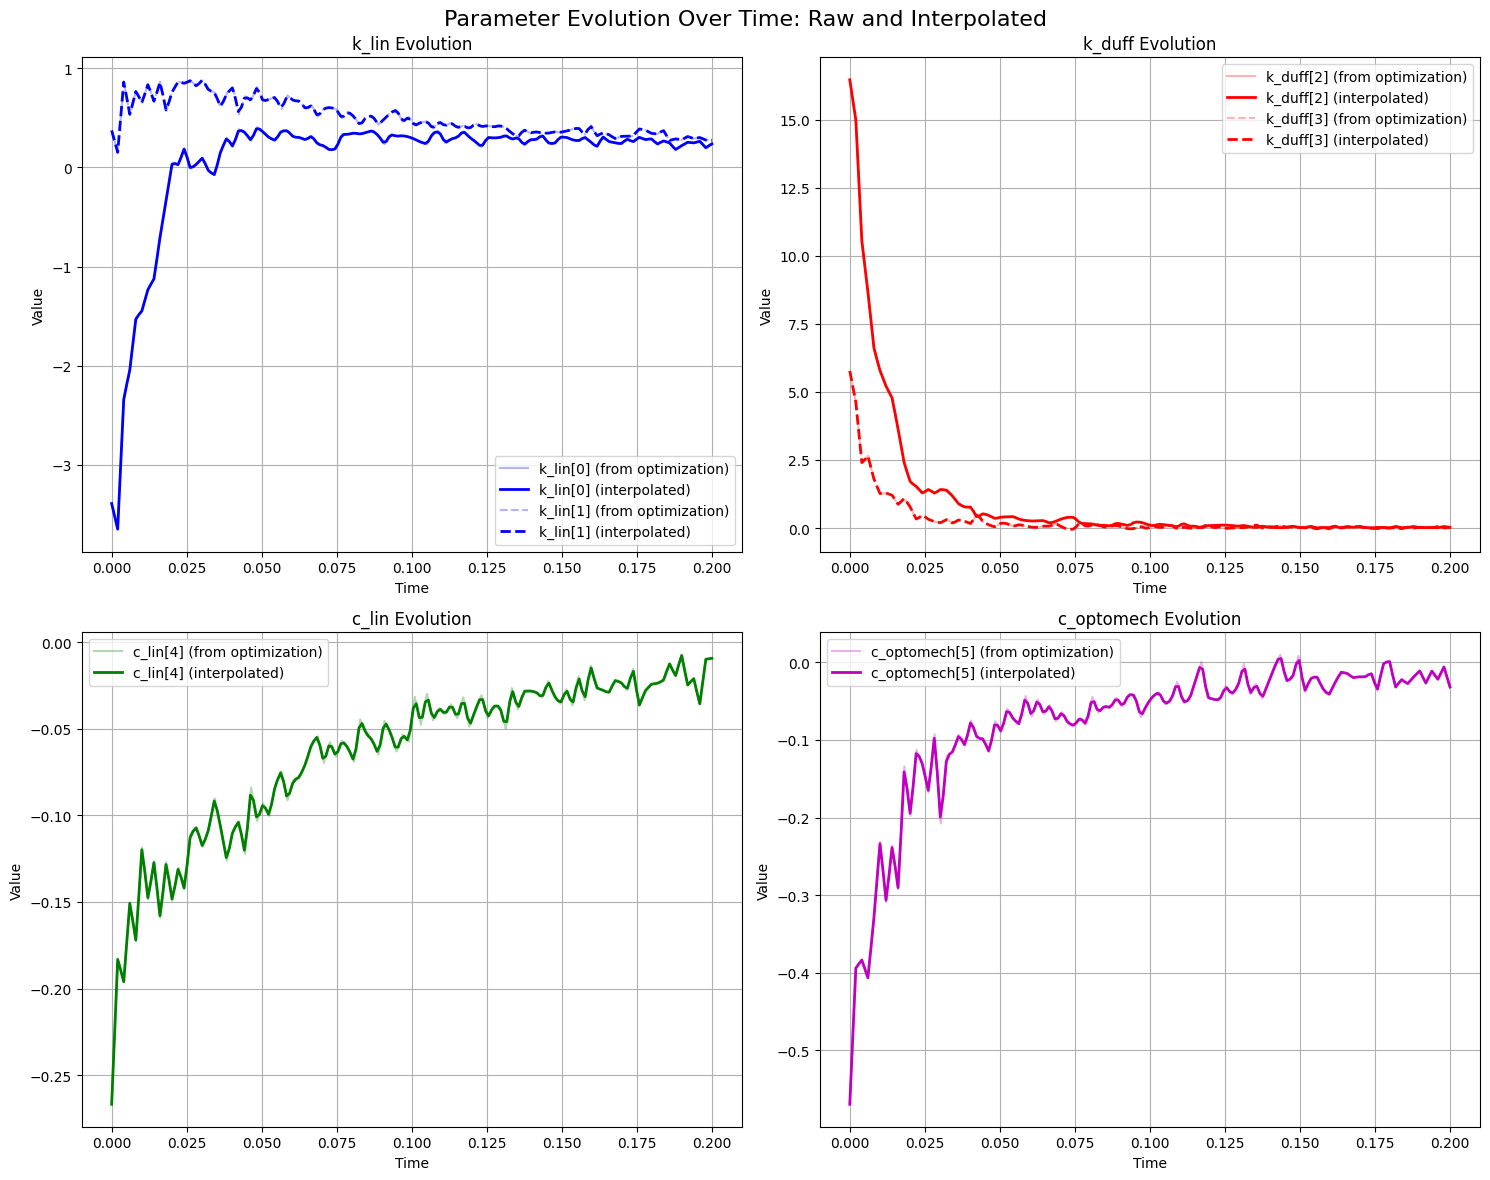

In [12]:
def smooth_parameters(params, window_lengths = [31, 31, 31, 31, 31, 31], poly_orders = [3, 3, 3, 3, 3, 3]):
    """
    Smooths multiple parameter trajectories using Savitzky-Golay filter
    
    Args:
        params: Array of shape (n_timesteps, n_params) containing parameter trajectories
        window_lengths: List/array of window lengths for each parameter dimension
        poly_orders: List/array of polynomial orders for each parameter dimension
    
    Returns:
        Array of shape (n_timesteps, n_params) containing smoothed parameter trajectories
    """
    n_params = params.shape[1]
    smoothed = []
    
    for i in range(n_params):
        # Ensure window length is odd and valid
        window_length = min(window_lengths[i], len(params) - (1 - len(params) % 2))
        if window_length % 2 == 0:
            window_length -= 1
            
        # Smooth using Savitzky-Golay filter
        smoothed.append(savgol_filter(params[:, i], window_length, poly_orders[i]))
    
    return jnp.column_stack(smoothed)

# def interpolate_parameters(params, time_points):
#     """
#     Interpolates parameter trajectories using cubic splines
    
#     Args:
#         params: Array of shape (n_timesteps, n_params) containing parameter trajectories
#         time_points: Original time points corresponding to params
#         time_points_dense: Time points at which to evaluate interpolation (optional)
    
#     Returns:
#         Interpolator function that takes time points and returns interpolated parameters
#     """
    
    
#     return CubicSpline(time_points, params)

def interpolate_parameters(params, time_points):
    """
    Interpolates parameter trajectories using jnp.interp in a vectorized fashion.

    Args:
        params: Array of shape (n_timesteps, n_params) containing parameter trajectories.
        time_points: 1D array of shape (n_timesteps,) corresponding to the time points.

    Returns:
        A function that takes time points `t` (scalar or 1D array) and returns
        the interpolated parameters. For scalar `t`, the result is shape (n_params,);
        for vector `t`, the result is shape (len(t), n_params).
    """
    
    def _interpolator(t):
        # Transpose params to shape (n_params, n_timesteps) so that each row is a trajectory.
        # Use vmap to apply jnp.interp over each parameter trajectory.
        interpolated = jax.vmap(lambda param: jnp.interp(t, time_points, param))(params.T)
        # If t is an array, jnp.interp returns an array for each parameter, resulting in a
        # (n_params, len(t)) array. Transpose it so that each row corresponds to a time point.
        if jnp.ndim(t) > 0:
            return interpolated.T
        return interpolated

    return _interpolator



# First smooth the parameters
smoothed_params = smooth_parameters(params_history_all_t)
# Get interpolator function
params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0],forward_time_pts[-1],200)
# interpolated_params = interpolate_parameters(smoothed_params, forward_time_pts, time_dense)
interpolated_params = params_interpolator(time_eval)

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Raw and Interpolated', fontsize=16)

# Plot settings
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = ['b', 'r', 'g', 'm']
param_indices = [(0,1), (2,3), (4,), (5,)]

# Plot for each parameter type
for ax, param_name, color, indices in zip(axes, param_names, colors, param_indices):
    for idx, style in zip(indices, ['-', '--']):
        # Plot raw data
        ax.plot(forward_time_pts, params_history_all_t[:, idx], color + style, alpha=0.3, 
                label=f'{param_name}[{idx}] (from optimization)')
        
        # Plot interpolated data
        ax.plot(time_eval, interpolated_params[:, idx], color + style, linewidth=2,
                label=f'{param_name}[{idx}] (interpolated)')
    
    ax.set_title(f'{param_name} Evolution')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

### Run reverse SDE:

In [32]:
t0 = 0.0
t1 = t_forward

forward_params = jnp.zeros_like(flattened_args_initial)
forward_params = forward_params.at[0].set(1.)
forward_params = forward_params.at[1].set(1.)
params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - forward_params

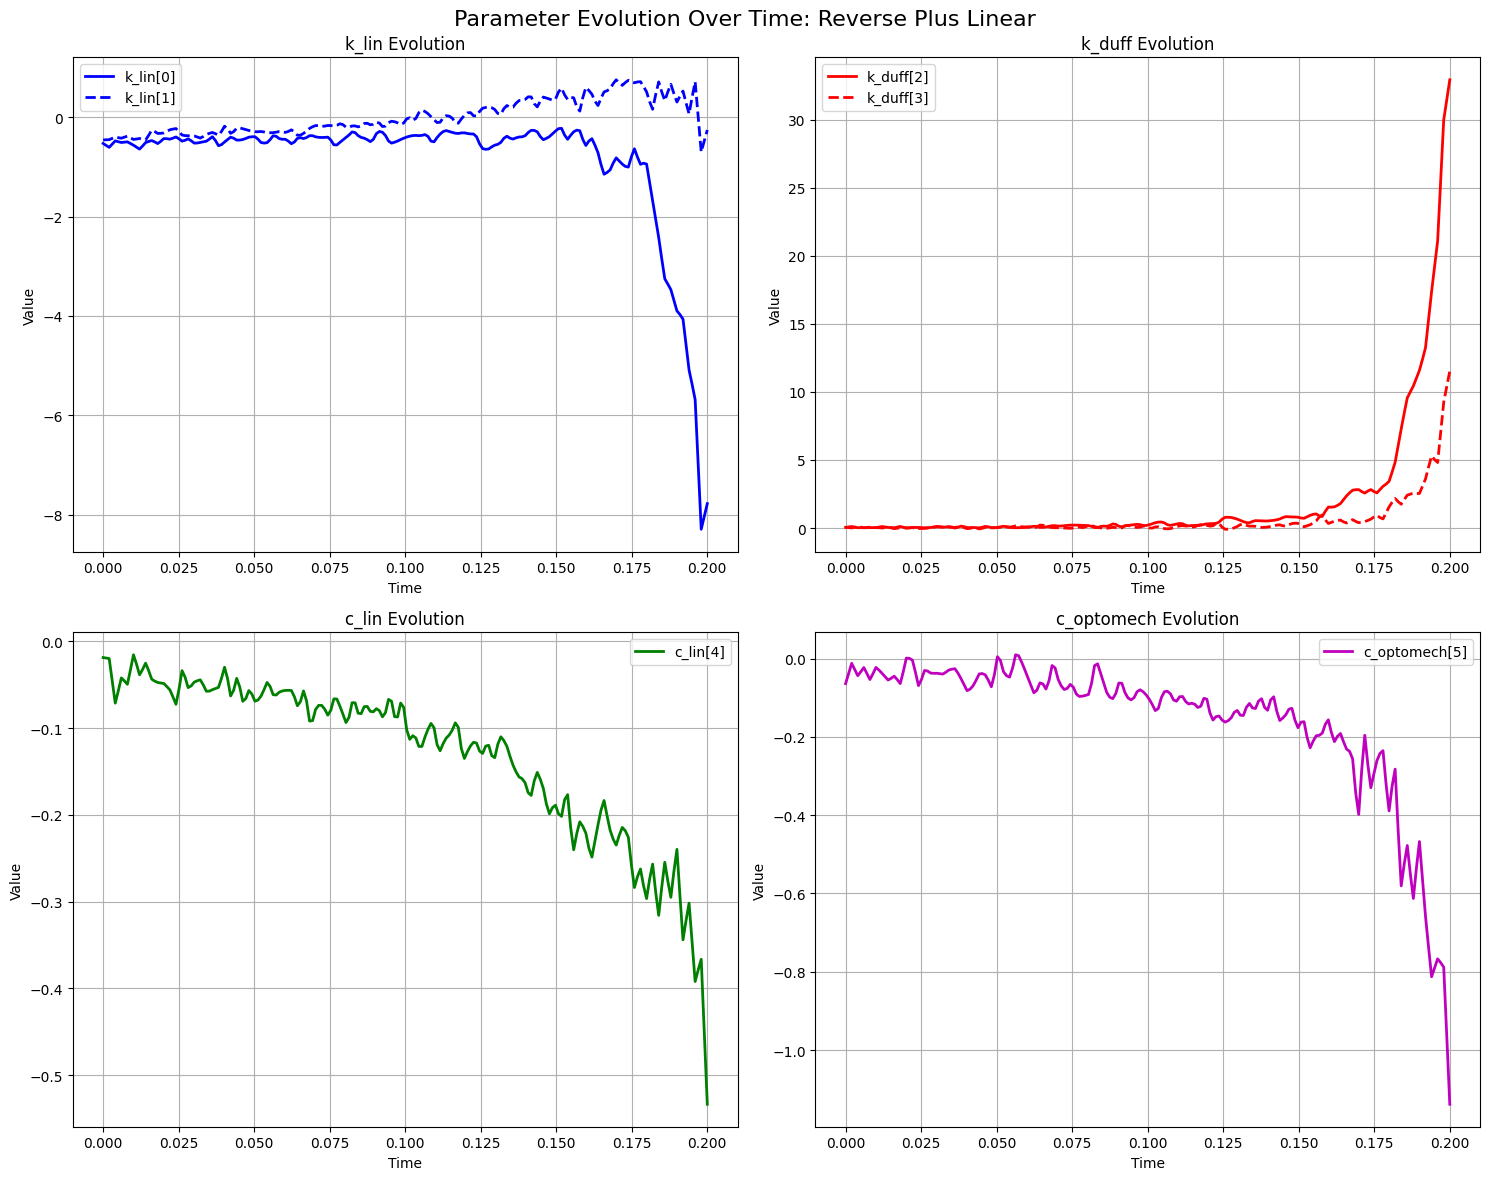

In [33]:
# Create time points for evaluation
time_eval = jnp.linspace(0, t_forward, 200)

# Get parameters at each time point
params_over_time = jnp.vstack([params_interpolator_reverse_plus_linear(t) for t in time_eval])

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Reverse Plus Linear', fontsize=16)

# Plot settings
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = ['b', 'r', 'g', 'm']
param_indices = [(0,1), (2,3), (4,), (5,)]

# Plot for each parameter type
for ax, param_name, color, indices in zip(axes, param_names, colors, param_indices):
    for idx, style in zip(indices, ['-', '--']):
        ax.plot(time_eval, params_over_time[:, idx], color + style, linewidth=2,
                label=f'{param_name}[{idx}]')
    
    ax.set_title(f'{param_name} Evolution')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [34]:
# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True)

ts = jnp.linspace(t0, t1, 10000)
dt0 = ts[1] - ts[0]

# Generate multiple initial states
n_trajectories = 2000
key, subkey = jr.split(key)
initial_states = sample_forward_process_minusx_plus_sqrt2D_dw(t_forward, n_trajectories, D=1, samples0=samples_0, key=subkey)

# Run SDE for each initial state
# all_trajectories = []
# for init_state in initial_states:
#     solution = solve_SDE(drift_fn, diffusion_fn, init_state, t0, t1, ts.shape[0], dt0)
#     all_trajectories.append(solution.ys)

# Vectorize solve_SDE across initial states
vectorized_solve_SDE = vmap(
    lambda init_state: solve_SDE(drift_fn, diffusion_fn, init_state, t0, t1, ts.shape[0], dt0)
)

# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states)
all_trajectories = solutions.ys  # Shape: (n_trajectories, n_timesteps, 2)
final_states = all_trajectories[:, -1, :]  # Shape: (n_trajectories, 2)

# Convert to array and get final states
all_trajectories = jnp.array(all_trajectories)
final_states = all_trajectories[:, -1, :]  # Shape: (n_trajectories, 2)

100.00%|##########| [00:29<00:00,  3.37%/s]


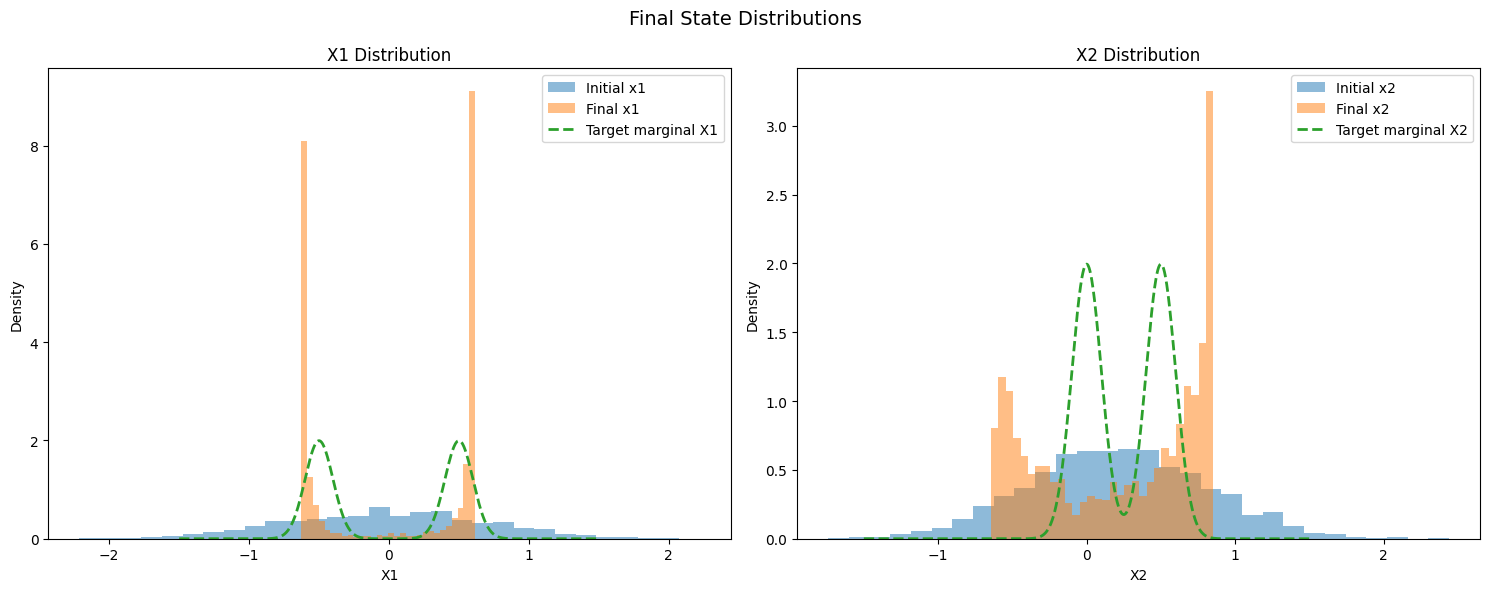

In [36]:
# Create plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Final State Distributions', fontsize=14)

# Plot initial and final distributions for x1
ax1.hist(initial_states[:, 0], bins=30, alpha=0.5, density=True, label='Initial x1')
ax1.hist(final_states[:, 0], bins=30, alpha=0.5, density=True, label='Final x1')

# Plot initial and final distributions for x2
ax2.hist(initial_states[:, 1], bins=30, alpha=0.5, density=True, label='Initial x2')
ax2.hist(final_states[:, 1], bins=30, alpha=0.5, density=True, label='Final x2')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim, ax in enumerate([ax1, ax2]):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax.plot(x, marginal, '--', linewidth=2, label=f'Target marginal {["X1", "X2"][dim]}')

ax1.set_title('X1 Distribution')
ax1.set_xlabel('X1')
ax1.set_ylabel('Density')
ax1.legend()

ax2.set_title('X2 Distribution')
ax2.set_xlabel('X2')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()